# Pipeline de Ingesta de Demanda Eléctrica Española (REE)

## Resumen

Este proyecto implementa un pipeline completo de datos para la extracción, transformación y almacenamiento de series temporales de demanda eléctrica procedentes de la API pública de Red Eléctrica de España (REE).

El sistema está diseñado para servir como base de casos de uso en analítica de datos energéticos, incluyendo monitorización, visualización operativa y modelos de forecasting.

## Objetivos

- Extracción de datos históricos y en tiempo real desde la API de REE.
- Transformación y normalización de series temporales.
- Agregación a granularidad horaria.
- Almacenamiento en InfluxDB.
- Implementación de ingesta incremental (pipeline continuo).
- Preparación de datos para dashboards y modelos predictivos.

## Arquitectura del sistema

![Arquitectura del pipeline](../images/architecture_overview.png)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import datetime
import time
import pickle

import pandas as pd
import requests

from influxdb_client import InfluxDBClient
from influxdb_client.client.write_api import SYNCHRONOUS

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import os

from dotenv import load_dotenv
from influxdb_client import InfluxDBClient

load_dotenv()

token = os.getenv("INFLUX_TOKEN")
org = os.getenv("INFLUX_ORG")
bucket = os.getenv("INFLUX_BUCKET")
url = os.getenv("INFLUX_URL")

required = {
    "INFLUX_TOKEN": token,
    "INFLUX_ORG": org,
    "INFLUX_BUCKET": bucket,
    "INFLUX_URL": url
}

missing = [k for k, v in required.items() if not v]

if missing:
    raise ValueError(
        f"Faltan variables de entorno: {', '.join(missing)}"
    )

client = InfluxDBClient(
    url=url,
    token=token
)

# Obtención de datos

La API pública de REE proporciona información de demanda eléctrica actualizada periódicamente.

En este proyecto utilizaremos:

- Demanda real.
- Demanda prevista por REE.

La extracción se realiza mediante peticiones HTTP GET parametrizadas por rango temporal.

In [3]:
def get_demand_data(
    start_date: datetime.datetime,
    end_date: datetime.datetime
) -> dict:
    """
    Descarga datos de demanda eléctrica desde REE.
    """

    url = (
        "https://apidatos.ree.es/en/datos/demanda/"
        "demanda-tiempo-real"
    )

    params = {
        "start_date": start_date.strftime("%Y-%m-%dT%H:%M"),
        "end_date": end_date.strftime("%Y-%m-%dT%H:%M"),
        "time_trunc": "hour"
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    return response.json()

# Transformación de datos

La respuesta de la API se transforma a un DataFrame preparado para análisis temporal.

Transformaciones realizadas:

- Extracción de variables relevantes.
- Conversión de timestamps a UTC.
- Agregación horaria.
- Homogeneización de nombres de columnas.

In [4]:
def process_response(data: dict) -> pd.DataFrame:

    real = pd.json_normalize(
        data["included"][0]["attributes"]["values"]
    )

    forecast = pd.json_normalize(
        data["included"][2]["attributes"]["values"]
    )

    real = real.rename(
        columns={"value": "RealDemand"}
    )

    forecast = forecast.rename(
        columns={"value": "ForecastDemand"}
    )

    df = (
        real[["datetime", "RealDemand"]]
        .merge(
            forecast[["datetime", "ForecastDemand"]],
            on="datetime"
        )
    )

    df["datetime"] = pd.to_datetime(
        df["datetime"],
        utc=True
    )

    df = (
        df
        .set_index("datetime")
        .resample("h")
        .mean()
        .round(1)
    )

    return df

# Exploración inicial

Antes de almacenar los datos se realiza una validación visual para comprobar:

- Continuidad temporal.
- Magnitud de la demanda.
- Coherencia entre demanda real y previsión.

In [5]:
sample = get_demand_data(
    datetime.datetime(2024, 1, 1),
    datetime.datetime(2024, 1, 2)
)

df = process_response(sample)

df.head()

,RealDemand,ForecastDemand
datetime,,
2023-12-31 23:00:00+00:00,23301.1,23352.2
2024-01-01 00:00:00+00:00,23409.4,22610.8
2024-01-01 01:00:00+00:00,21800.4,21386.1
2024-01-01 02:00:00+00:00,20052.9,20141.3
2024-01-01 03:00:00+00:00,19350.6,19354.6


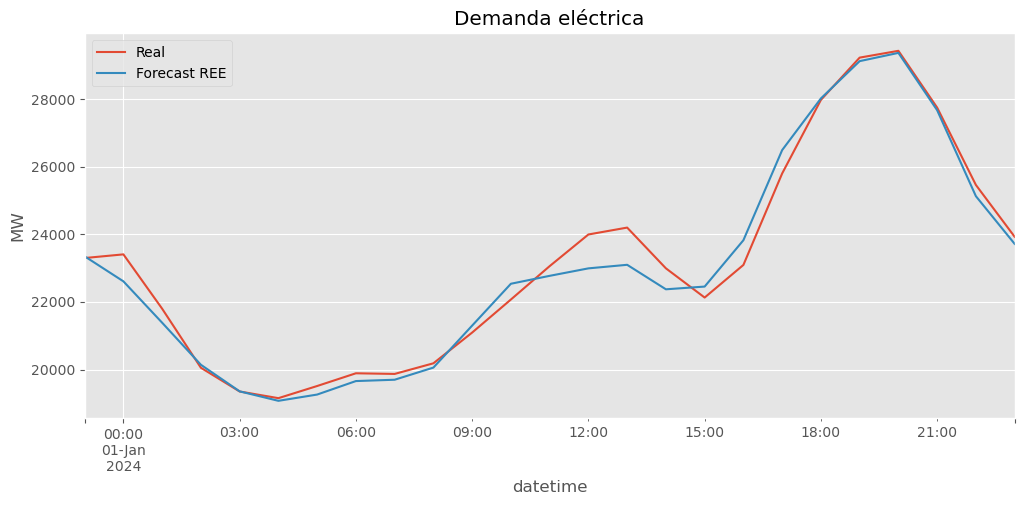

In [6]:
fig, ax = plt.subplots(figsize=(12,5))

df["RealDemand"].plot(ax=ax, label="Real")
df["ForecastDemand"].plot(ax=ax, label="Forecast REE")

ax.set_title("Demanda eléctrica")
ax.set_ylabel("MW")
ax.legend()

plt.show()

# Almacenamiento en InfluxDB

InfluxDB se utiliza como base de datos especializada en series temporales.

Cada observación se almacena bajo la medición:

demand

Campos:

- RealDemand
- ForecastDemand

In [7]:
def save_to_influxdb(
    df: pd.DataFrame,
    client: InfluxDBClient,
    bucket: str,
    org: str
) -> None:

    write_api = client.write_api(
        write_options=SYNCHRONOUS
    )

    write_api.write(
        bucket=bucket,
        org=org,
        record=df,
        data_frame_measurement_name="demand"
    )

# Estrategia de ingesta incremental

Para evitar reprocesamientos innecesarios se mantiene un registro de los días ya cargados.

Ventajas:

- Menor consumo de API.
- Recuperación ante fallos.
- Escalabilidad para históricos extensos.

In [8]:
from datetime import timedelta

In [9]:
def ingest_data(start_date, client, bucket, org):

    end_date = datetime.datetime.now(datetime.timezone.utc)

    current_day = start_date

    processed = []

    while current_day <= end_date:

        try:

            day_end = current_day + datetime.timedelta(days=1) - datetime.timedelta(minutes=1)

            raw = get_demand_data(current_day, day_end)

            df = process_response(raw)

            save_to_influxdb(df, client, bucket, org)

            processed.append(current_day)

        except Exception as e:

            print(f"Error en {current_day}: {e}")
            break

        current_day += datetime.timedelta(days=1)

    return processed

# Persistencia del progreso

Se almacena localmente el conjunto de días ya procesados para permitir la reanudación automática del pipeline.

In [10]:
def get_last_timestamp(client, bucket, org):

    query_api = client.query_api()

    query = f'''
    from(bucket: "{bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "demand")
      |> sort(columns: ["_time"], desc: true)
      |> limit(n:1)
    '''

    tables = query_api.query(query, org=org)

    for table in tables:
        for record in table.records:
            return record.get_time()

    return None

# Actualización continua

El proceso puede ejecutarse de forma periódica para mantener sincronizada la base de datos con los datos publicados por REE.

In [ ]:
while True:

    last_ts = get_last_timestamp(client, bucket, org)

    if last_ts is None:
        start_date = datetime.datetime(2022, 1, 1, tzinfo=datetime.timezone.utc)
    else:
        start_date = last_ts

        if start_date.tzinfo is None:
            start_date = start_date.replace(tzinfo=datetime.timezone.utc)

        start_date = start_date + datetime.timedelta(minutes=10)

    print(f"Reanudando desde: {start_date}")

    processed = ingest_data(
        start_date=start_date,
        client=client,
        bucket=bucket,
        org=org
    )

    print("Pipeline actualizado")

    time.sleep(3600)  

Reanudando desde: 2026-06-11 08:10:00+00:00
Pipeline actualizado


# Conclusiones

Se ha desarrollado un pipeline completo para la adquisición y almacenamiento de datos energéticos en tiempo real.

Aspectos destacados:

- Consumo de API REST.
- Procesamiento de series temporales.
- Gestión de zonas horarias.
- Persistencia en InfluxDB.
- Ingesta incremental robusta.
- Base preparada para modelos de forecasting.

Este pipeline constituye una solución reutilizable para proyectos de monitorización energética y analítica temporal.